In [1]:
import pandas as pd

In [2]:
USD_data = pd.read_csv('/Users/yitik/Desktop/Dersler/For Python/InvestGuide/investment_ml/rawData/EUR_rawDataset.csv')
df = USD_data.copy()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1244 entries, 0 to 1243
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Tarih          1244 non-null   object 
 1   Yıl            1244 non-null   int64  
 2   Ay             1244 non-null   int64  
 3   Birim          1244 non-null   object 
 4   Alış (Forex)   1244 non-null   float64
 5   Satış (Forex)  1244 non-null   float64
dtypes: float64(2), int64(2), object(2)
memory usage: 58.4+ KB


In [5]:
df.head()

,Tarih,Yıl,Ay,Birim,Alış (Forex),Satış (Forex)
0,2020-12-07,2020,12,Euro (EUR),9.4913,9.5084
1,2020-12-08,2020,12,Euro (EUR),9.4620,9.4790
2,2020-12-09,2020,12,Euro (EUR),9.4840,9.5011
3,2020-12-10,2020,12,Euro (EUR),9.4932,9.5103
4,2020-12-11,2020,12,Euro (EUR),9.6241,9.6414


In [7]:
df['Gun'] = df['Tarih'].apply(lambda x: int(x[-2:]))

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1244 entries, 0 to 1243
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Tarih          1244 non-null   object 
 1   Yıl            1244 non-null   int64  
 2   Ay             1244 non-null   int64  
 3   Birim          1244 non-null   object 
 4   Alış (Forex)   1244 non-null   float64
 5   Satış (Forex)  1244 non-null   float64
 6   Gun            1244 non-null   int64  
dtypes: float64(2), int64(3), object(2)
memory usage: 68.2+ KB


In [11]:
df['Tarih'] = pd.to_datetime(df['Tarih'])
df = df.sort_values(by = 'Tarih')
df = df.reset_index(drop=True)

In [13]:
df['Haftalik_Ortalama'] = df['Alış (Forex)'].rolling(window=7).mean()

In [15]:
df['Onceki_Gun_Fiyat'] = df['Alış (Forex)'].shift(1)

In [17]:
df.dropna(inplace = True)

In [19]:
df.reset_index(drop=True, inplace=True)

In [21]:
df.head()

,Tarih,Yıl,Ay,Birim,Alış (Forex),Satış (Forex),Gun,Haftalik_Ortalama,Onceki_Gun_Fiyat
0,2020-12-15,2020,12,Euro (EUR),9.5184,9.5355,15,9.519343,9.5624
1,2020-12-16,2020,12,Euro (EUR),9.4908,9.5079,16,9.519271,9.5184
2,2020-12-17,2020,12,Euro (EUR),9.4817,9.4988,17,9.522086,9.4908
3,2020-12-18,2020,12,Euro (EUR),9.4230,9.4400,18,9.513371,9.4817
4,2020-12-21,2020,12,Euro (EUR),9.3504,9.3672,21,9.492971,9.4230


In [23]:
df.drop(columns = 'Birim', inplace = True)

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1238 entries, 0 to 1237
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Tarih              1238 non-null   datetime64[ns]
 1   Yıl                1238 non-null   int64         
 2   Ay                 1238 non-null   int64         
 3   Alış (Forex)       1238 non-null   float64       
 4   Satış (Forex)      1238 non-null   float64       
 5   Gun                1238 non-null   int64         
 6   Haftalik_Ortalama  1238 non-null   float64       
 7   Onceki_Gun_Fiyat   1238 non-null   float64       
dtypes: datetime64[ns](1), float64(4), int64(3)
memory usage: 77.5 KB


In [27]:
df.isna().sum()

Tarih                0
Yıl                  0
Ay                   0
Alış (Forex)         0
Satış (Forex)        0
Gun                  0
Haftalik_Ortalama    0
Onceki_Gun_Fiyat     0
dtype: int64

In [29]:
df.head()

,Tarih,Yıl,Ay,Alış (Forex),Satış (Forex),Gun,Haftalik_Ortalama,Onceki_Gun_Fiyat
0,2020-12-15,2020,12,9.5184,9.5355,15,9.519343,9.5624
1,2020-12-16,2020,12,9.4908,9.5079,16,9.519271,9.5184
2,2020-12-17,2020,12,9.4817,9.4988,17,9.522086,9.4908
3,2020-12-18,2020,12,9.4230,9.4400,18,9.513371,9.4817
4,2020-12-21,2020,12,9.3504,9.3672,21,9.492971,9.4230


In [31]:
X = df[['Yıl', 'Ay', 'Gun', 'Onceki_Gun_Fiyat', 'Haftalik_Ortalama']]
y = df['Alış (Forex)']

In [33]:
from sklearn.model_selection import train_test_split

In [35]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

In [37]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet, HuberRegressor, BayesianRidge
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

In [39]:
models = {
    # --- Temel Model ---
    "Linear Regression": LinearRegression(),
    
    # --- Regularization (Ceza) Ekleyen Modeller ---
    # Overfitting'i engeller, değişkenler arası korelasyonu (dolar vs euro gibi) yönetir.
    "Ridge": Ridge(random_state=42),
    "Lasso": Lasso(random_state=42),
    "ElasticNet": ElasticNet(random_state=42),
    
    # --- Gürültüye Dayanıklı (Robust) Modeller ---
    # Altın fiyatlarındaki ani iğne atışlarını (outlier) görmezden gelerek trendi yakalar.
    "Huber Regressor": HuberRegressor(max_iter=2000), # Yakınsama için iterasyonu artırdık
    "Bayesian Ridge": BayesianRidge(),
    
    # --- Ağaç Tabanlı Modeller (Kıyaslama için) ---
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "XGBoost": XGBRegressor(objective='reg:squarederror', n_estimators=100, random_state=42)
}

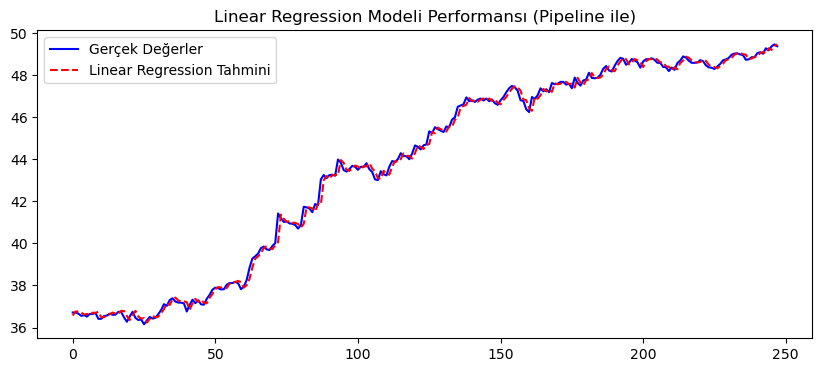

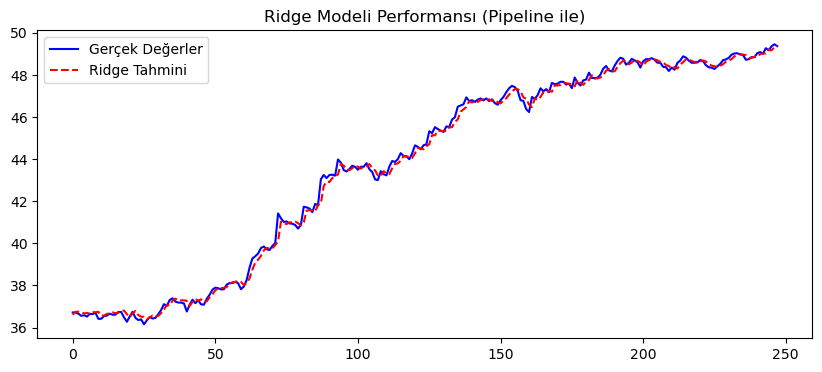

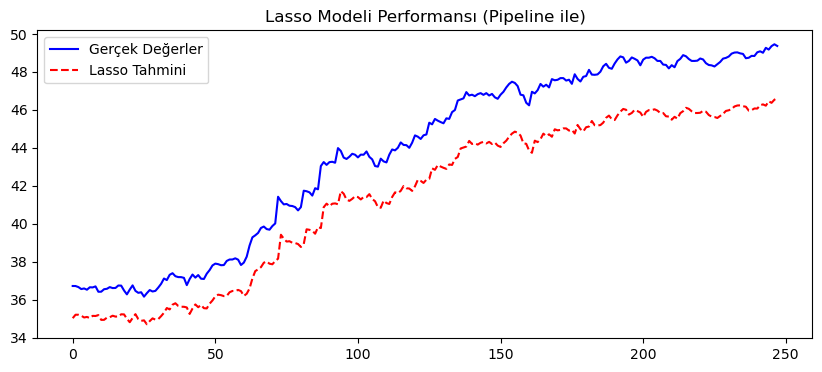

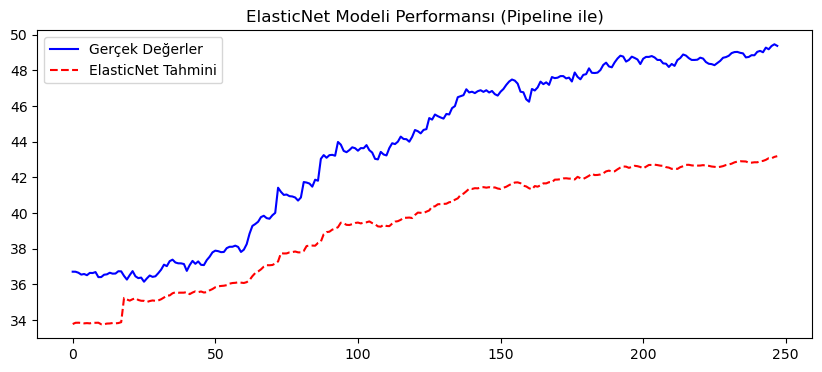

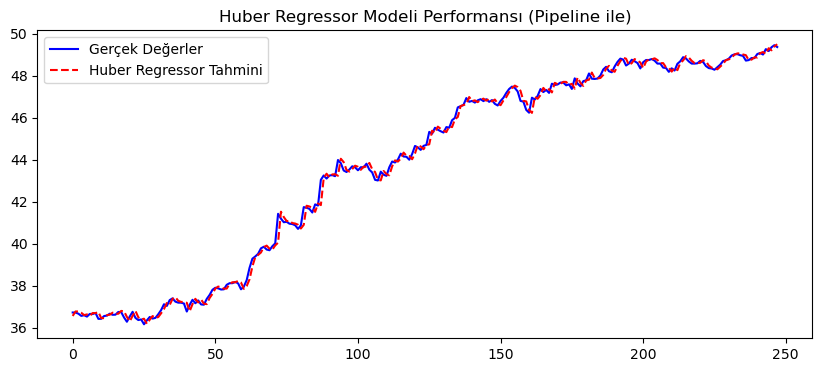

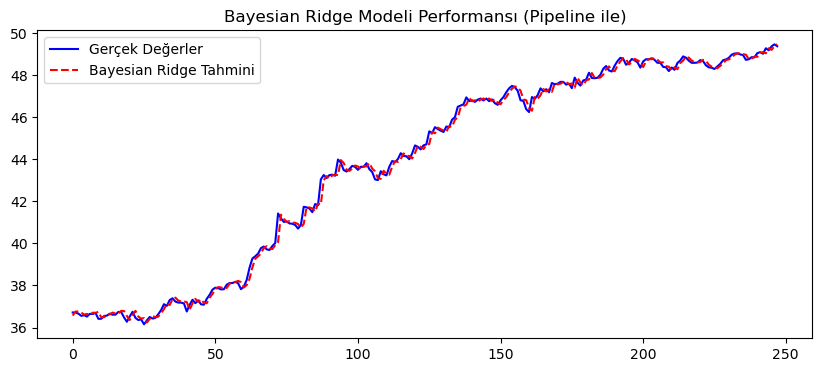

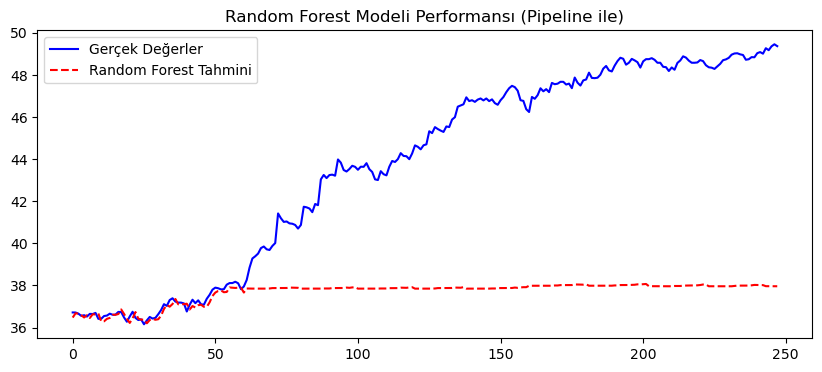

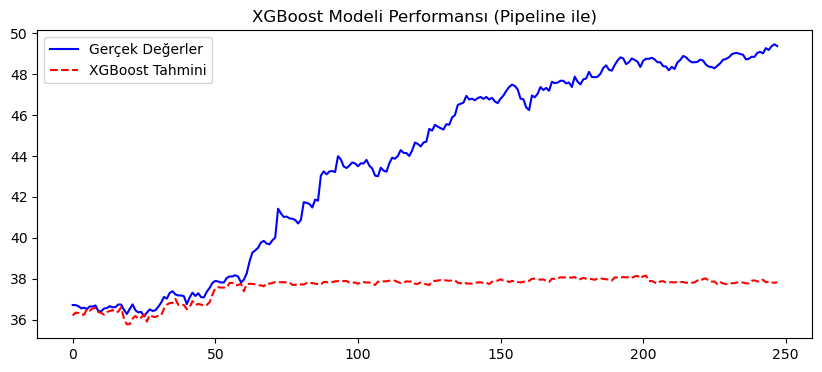

               Model  MAE (Ort. Hata TL)      RMSE  R2 Score (Başarı)
5     Bayesian Ridge            0.160124  0.227856           0.997554
0  Linear Regression            0.160217  0.227963           0.997552
4    Huber Regressor            0.164810  0.233270           0.997437
1              Ridge            0.166626  0.235407           0.997390
2              Lasso            2.291684  2.349376           0.740004
3         ElasticNet            4.318033  4.618284          -0.004671
6      Random Forest            6.102341  7.401025          -1.580158
7            XGBoost            6.193180  7.450961          -1.615093


In [41]:
import numpy as np
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler # Finans verisi için genelde bu kullanılır
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

results = []
best_score = -np.inf # En iyi skoru takip etmek için (R2'ye göre)
best_pipeline = None # En iyi modeli (pipeline halini) saklamak için
best_model_name = ""

# Döngü
for name, model in models.items():
    
    # --- DEĞİŞİKLİK BURADA BAŞLIYOR ---
    # 1. Pipeline Oluşturma: Önce veriyi Standartlaştır, sonra Modeli çalıştır.
    # Bu sayede 'scaler' sadece X_train istatistiklerini öğrenir, X_test'i buna göre dönüştürür.
    pipe = make_pipeline(StandardScaler(), model)
    
    # 2. Modeli Eğit (Pipeline üzerinden)
    pipe.fit(X_train, y_train)
    
    # 3. Tahmin Yap (Pipeline, X_test'i otomatik scale edip tahmin üretir)
    predictions = pipe.predict(X_test)
    # --- DEĞİŞİKLİK BURADA BİTİYOR ---

    # Metrikleri Hesapla
    mae = mean_absolute_error(y_test, predictions)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    r2 = r2_score(y_test, predictions)
    
    # Sonuçları listeye ekle
    results.append({
        "Model": name,
        "MAE (Ort. Hata TL)": mae,
        "RMSE": rmse,
        "R2 Score (Başarı)": r2
    })
    
    # En iyi modeli hafızada tut (R2 skoruna göre)
    if r2 > best_score:
        best_score = r2
        best_pipeline = pipe # Eğitilmiş pipeline'ı saklıyoruz
        best_model_name = name

    # Grafik Çiz
    plt.figure(figsize=(10, 4))
    plt.plot(y_test.values, label='Gerçek Değerler', color='blue')
    plt.plot(predictions, label=f'{name} Tahmini', color='red', linestyle='--')
    plt.title(f'{name} Modeli Performansı (Pipeline ile)')
    plt.legend()
    plt.show()

# Sonuçları Göster
import pandas as pd
df_results = pd.DataFrame(results).sort_values(by="R2 Score (Başarı)", ascending=False)
print(df_results)

In [43]:
import pandas as pd
import numpy as np
from sklearn.linear_model import BayesianRidge
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# --- Veri Hazırlığı ---
# X_train, y_train, X_test, y_test değişkenlerinin hafızada olduğunu varsayıyorum.

# 1. Pipeline Kurulumu
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('bayes', BayesianRidge())
])

# 2. Parametre Izgarası (DÜZELTİLDİ)
# 'n_iter' yerine 'max_iter' kullanıyoruz.
param_grid = {
    'bayes__max_iter': [300, 500, 1000],   # Düzelttim: n_iter -> max_iter
    'bayes__alpha_1': [1e-7, 1e-6, 1e-5],  # Gürültü parametreleri
    'bayes__alpha_2': [1e-7, 1e-6, 1e-5],
    'bayes__lambda_1': [1e-7, 1e-6, 1e-5], # Ağırlık parametreleri
    'bayes__lambda_2': [1e-7, 1e-6, 1e-5]
}

# 3. Zaman Serisi Bölücüsü
tscv = TimeSeriesSplit(n_splits=5)

# 4. GridSearch Başlat
print("Bayesian Ridge modeli için en iyi parametreler aranıyor...")
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=tscv,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

# Aramayı Başlat
grid_search.fit(X_train, y_train)

# --- SONUÇLAR ---
print(f"\nEn İyi Parametreler: {grid_search.best_params_}")
print(f"En İyi Skor (Negatif MSE): {grid_search.best_score_}")

best_bayes_model = grid_search.best_estimator_

if 'X_test' in locals() and 'y_test' in locals():
    y_pred = best_bayes_model.predict(X_test)
    
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    
    print("\n--- TEST SETİ PERFORMANSI ---")
    print(f"MAE: {mae:.6f}")
    print(f"RMSE: {rmse:.6f}")
    print(f"R2 Score: {r2:.6f}")

Bayesian Ridge modeli için en iyi parametreler aranıyor...
Fitting 5 folds for each of 243 candidates, totalling 1215 fits

En İyi Parametreler: {'bayes__alpha_1': 1e-05, 'bayes__alpha_2': 1e-07, 'bayes__lambda_1': 1e-07, 'bayes__lambda_2': 1e-05, 'bayes__max_iter': 300}
En İyi Skor (Negatif MSE): -0.07157453084974061

--- TEST SETİ PERFORMANSI ---
MAE: 0.160124
RMSE: 0.227856
R2 Score: 0.997554
